# Introduction

This project aims to determine which city receives more rain: Seattle or Vancouver.
Knowing which city rains more can support decisions in many ways. For example, a traveler choosing between Seattle and Vancouver for a summer trip may want the city with a lower chance of rain, to avoid being stuck in a hotel room. Businesses in outdoor recreation, transportation, and travel also depend on weather patterns when deciding whether to expand into a new city.
However, "rains more" can be defined in several ways. In this project, I use two definitions:
1.	Frequency of rain: whether it rains at all on a given day (precipitation > 0).
2.	Total precipitation: the absolute amount of precipitation.
I compare the two cities under each definition across three time scales: the entire period of interest (January 1, 2018 to December 31, 2022), seasonal, and monthly.

# About the Data

The data for this project were obtained from the National Oceanic and Atmospheric Administration (NOAA) GHCN Daily database. The dataset contains daily precipitation records measured in inches for Seattle (station: USW00094290) and Vancouver (station: CA001108395). The study period covers 1,826 days for each of the two cities (from January 1, 2018, to December 31, 2022), yielding 3,652 city-day observations. Of these, 3 (0.1%) had no recorded precipitation value (3 for Vancouver). These missing values were imputed using the mean precipitation of the same calendar day across the other years. After imputation, all 3,652 city-day observations (1,826 per city) had a precipitation value.


Link to the data source : https://www.ncei.noaa.gov/cdo-web/search?datasetid=GHCND

# Load and explore the data

## Import libraries

In [797]:
# Import nessessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy
import calendar
from scipy import stats

# seaborn is a data visualization library built on matplotlib
import seaborn as sns



# set the plotting style
sns.set_style("whitegrid")

## Load the data

##### Load the Seattle and Vancouver data set

In [798]:
df_seattle = pd.read_csv("/Users/jisoo/Desktop/MSDS/26_Fall/DATA5100/weather/data/seattle_weather.csv")
df_vancouver = pd.read_csv("/Users/jisoo/Desktop/MSDS/26_Fall/DATA5100/weather/data/van.csv")

## Explore the contents of the data sets

##### Start by looking at the head of each data frame.

This will let us see the names of the columns and a few example values for each column.

In [799]:
df_seattle.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,WT05,WT06,WT08
0,USW00094290,"SEATTLE SAND POINT WEATHER FORECAST OFFICE, WA US",2018-01-01,0.00,0.0,0.0,NaN,44,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00094290,"SEATTLE SAND POINT WEATHER FORECAST OFFICE, WA US",2018-01-02,0.00,0.0,0.0,NaN,45,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00094290,"SEATTLE SAND POINT WEATHER FORECAST OFFICE, WA US",2018-01-03,0.00,0.0,0.0,NaN,49,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00094290,"SEATTLE SAND POINT WEATHER FORECAST OFFICE, WA US",2018-01-04,0.09,0.0,0.0,NaN,46,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00094290,"SEATTLE SAND POINT WEATHER FORECAST OFFICE, WA US",2018-01-05,0.36,0.0,0.0,NaN,51,44.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [800]:
df_vancouver.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WSFG
0,CA001108395,"VANCOUVER INTERNATIONAL A, BC CA",2018-01-01,0.00,0.0,NaN,31.0,37.0,24.0,0.0,0.0
1,CA001108395,"VANCOUVER INTERNATIONAL A, BC CA",2018-01-02,0.00,0.0,NaN,32.0,37.0,26.0,0.0,0.0
2,CA001108395,"VANCOUVER INTERNATIONAL A, BC CA",2018-01-03,0.00,0.0,NaN,34.0,39.0,29.0,0.0,0.0
3,CA001108395,"VANCOUVER INTERNATIONAL A, BC CA",2018-01-04,0.00,0.0,NaN,38.0,42.0,35.0,0.0,0.0
4,CA001108395,"VANCOUVER INTERNATIONAL A, BC CA",2018-01-05,0.86,0.0,NaN,45.0,49.0,40.0,0.0,0.0


##### Use the `info` method to check the data types, size of the data frame, and numbers of missing values.

In [801]:
df_seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
 6   TAVG     0 non-null      float64
 7   TMAX     1826 non-null   int64  
 8   TMIN     1824 non-null   float64
 9   WT01     242 non-null    float64
 10  WT02     27 non-null     float64
 11  WT03     17 non-null     float64
 12  WT04     2 non-null      float64
 13  WT05     4 non-null      float64
 14  WT06     1 non-null      float64
 15  WT08     48 non-null     float64
dtypes: float64(12), int64(1), str(3)
memory usage: 228.4 KB


##### Vancouver data set

In [802]:
df_vancouver.info()

<class 'pandas.DataFrame'>
RangeIndex: 3621 entries, 0 to 3620
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  3621 non-null   str    
 1   NAME     3621 non-null   str    
 2   DATE     3621 non-null   str    
 3   PRCP     3514 non-null   float64
 4   SNOW     1811 non-null   float64
 5   SNWD     68 non-null     float64
 6   TAVG     3598 non-null   float64
 7   TMAX     3599 non-null   float64
 8   TMIN     3600 non-null   float64
 9   WDFG     1925 non-null   float64
 10  WSFG     1847 non-null   float64
dtypes: float64(8), str(3)
memory usage: 311.3 KB


##### Use the describe method to check the center, spread, and range of each numerical variables.

In [803]:
df_seattle.describe()

,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,WT05,WT06,WT08
count,1826.000000,1826.000000,1826.000000,0.0,1826.000000,1824.000000,242.0,27.0,17.0,2.0,4.0,1.0,48.0
mean,0.104704,0.017744,0.031325,NaN,61.452903,46.211075,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,0.227059,0.212700,0.307449,NaN,13.074841,9.337511,0.0,0.0,0.0,0.0,0.0,NaN,0.0
min,0.000000,0.000000,0.000000,NaN,25.000000,17.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,0.000000,0.000000,0.000000,NaN,51.000000,39.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,0.000000,0.000000,0.000000,NaN,60.000000,46.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,0.110000,0.000000,0.000000,NaN,72.000000,54.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,2.640000,6.100000,5.900000,NaN,107.000000,73.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [804]:
df_vancouver.describe()

,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WDFG,WSFG
count,3514.000000,1811.000000,68.000000,3598.000000,3599.000000,3600.000000,1925.000000,1847.000000
mean,0.115598,0.048923,1.941176,51.152863,57.594054,44.653611,17.614026,80.195885
std,0.254324,0.445434,2.241550,11.108307,12.238322,10.489718,10.119613,35.971769
min,0.000000,0.000000,0.000000,11.000000,18.000000,4.000000,0.000000,0.000000
25%,0.000000,0.000000,0.400000,43.000000,48.000000,37.000000,10.000000,71.600000
50%,0.000000,0.000000,0.800000,50.000000,56.000000,44.000000,18.000000,82.800000
75%,0.110000,0.000000,2.800000,61.000000,68.000000,53.000000,28.000000,98.400000
max,2.640000,9.500000,8.700000,80.000000,91.000000,69.000000,36.000000,210.300000


##### Use the shape attribute to check the number of rows and columns

In [805]:
df_seattle.shape

(1826, 16)

In [806]:
df_vancouver.shape

(3621, 11)

##### Use the columns attribute to check the columns

In [807]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX',
       'TMIN', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT06', 'WT08'],
      dtype='str')

In [808]:
df_vancouver.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX',
       'TMIN', 'WDFG', 'WSFG'],
      dtype='str')

### Examine the `STATION` column

##### From the shape attribute, we can see that the Vancouver dataframe has about twice as many rows as the Seattle dataframe. We will use the `unique()` method to determine whether this difference is due to the number of stations included.

In [809]:
df_vancouver['STATION'].unique()

<StringArray>
['CA001108395', 'CA001108380']
Length: 2, dtype: str

In [810]:
df_seattle['STATION'].unique()

<StringArray>
['USW00094290']
Length: 1, dtype: str

This result confirms that the Vancouver dataframe includes records from two stations. 
Since records from only one station are needed, we need to decide which station’s records to use.
Below is the code to check which station has less missing vlaues.

In [811]:
vancouver_station = df_vancouver['STATION'].unique()
for station in vancouver_station:
    print(station,
          ':', 
          df_vancouver.loc[df_vancouver['STATION'] == station,['PRCP']].isna().sum().item(),
         'missing values')

CA001108395 : 3 missing values
CA001108380 : 104 missing values


Since station CA001108395 has fewer missing values, we will use its records.
Below is the code to exclude the records from station CA001108380.

In [812]:
df_vancouver = df_vancouver.loc[df_vancouver['STATION'] == 'CA001108395']

### Convert `DATE` to datetime

From the `info()` method, we confirmed that the `DATE` column is stored as a string rather than a datetime type. We need to convert the `DATE` column to the appropriate datetime type for further analysis. Below is the code for convertion.

In [813]:
df_seattle['DATE']=pd.to_datetime(df_seattle['DATE'])
df_vancouver['DATE']=pd.to_datetime(df_vancouver['DATE'])

### What range of dates are present?

Since we changed the DATE column to the datetime type, we can use the `min()` and `max()` functions to check the date range of the data. The code below checks the date range.

In [814]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

In [815]:
df_van['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[us]

This confirms that the date range is from 2018-01-01 to 2022-12-31.

# Join data frames keeping `DATE` and `PRCP` columns

Now we will join the `df_vancouver` and `df_seattle` dataframes into a single dataframe. We will use an `outer` join because we want to include all dates present in either dataframe.

In [816]:
df = df_vancouver[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on = 'DATE', how ='outer')

In [817]:
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.00,0.09
4,2018-01-05,0.86,0.36


The results above show that the data from the two cities have been merged successfully. However, the suffixes `_x` and `_y` were added to the column names, making them less informative.

For further analysis, we should convert the current dataframe to a tidy format. Tidy data means that each column represents one variable, each row represents one observation, and each cell contains one value.

Since city is an important variable in this project, we will add a `CITY` column to identify the city. This structure will make the data easier to visualize and analyze.

### Create a tidy data frame with columns for city and precipitation

`melt()` is a useful function for converting a dataframe into tidy format.
`id_vars` specifies the data I want to keep unchanged.
`var_name` specifies the name of the variable I want to create.
`value_name` specifies the name of the new column that stores the values from the original columns.

In [818]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name = 'precipitation')

Now we have a tidy dataframe whose name is `df`

### Rename columns or values to follow best practices

We replace the original city values with shorter and more informative names. PRCP_x is changed to VAN for Vancouver, while PRCP_y is changed to SEA for Seattle. Also, we will rename the columns to be lowercase using `df.rename()`

In [819]:
df.loc[df['city'] == 'PRCP_x','city'] = 'VAN'
df.loc[df['city'] == 'PRCP_y','city'] = 'SEA'
df = df.rename(columns={'DATE':'date'})

## Identify and fill in missing values

We want to check whether all data are available between January 1, 2018 and December 31, 2022. Therefore, we compare the expected number of dates in the study period with the number of rows in the dataset.

In [820]:
from datetime import date

date1 = date(2018, 1, 1)
date2 = date(2022, 12, 31)

dates = (date2 - date1).days +1

df.shape[0] ==dates*2

True

The result shows that all rows for the study period are present.

We need to check how many missing vlaues are in each cities.
We group the data by city and count the number of missing values in the precipitation column for each city.

In [821]:
df.groupby('city')['precipitation'].agg(lambda x : x.isna().sum())

city
SEA    0
VAN    3
Name: precipitation, dtype: int64

From this result, we can confirm that Vancouver has 3 missing values.

### Impute missing values

We will replace missing values with the mean across years of values on that day.

This code adds the day_of_year column to the df

In [822]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

Now for every day_of_year, we calculate the mean across years of values on that day

In [823]:
mean_day_precipitation_VAN = df.loc[
    df['city']=='VAN',
    ['precipitation','day_of_year']
    ].groupby('day_of_year').mean()

`indices_VAN` is made to point the rows where the precipitation data doesn't exist.

In [824]:
indices_VAN = np.where((df['precipitation'].isna() == True) & (df['city'] == 'VAN'))[0]

Now replace the NaN values with the mean.

In [825]:
for index in indices_VAN :
    df.loc[index,'precipitation'] = mean_day_precipitation_VAN.loc[df.loc[index, 'day_of_year']].values[0]

Check if the replacement worked well.

In [826]:
df.isna().sum()

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

Since all the categories show 0, we can confirm that there is no Na values anyomore.

#### Export the clean .csv file

We will save this dataframe as a separate file and dataframe named clean_df.
We save the dataframe after imputing the missing values so that the cleaned dataset can be preserved and reused for further analysis.
`to_csv` function let us save the dataframe to CSV file.

In [827]:
df.to_csv('clean_seattle_vancouver_weather.csv', encoding='utf-8-sig', index=False)
clean_df = pd.read_csv("clean_seattle_vancouver_weather.csv")

# Analyzing the data

To get a grisp about the precipitation of both cities, draw a lineplot.

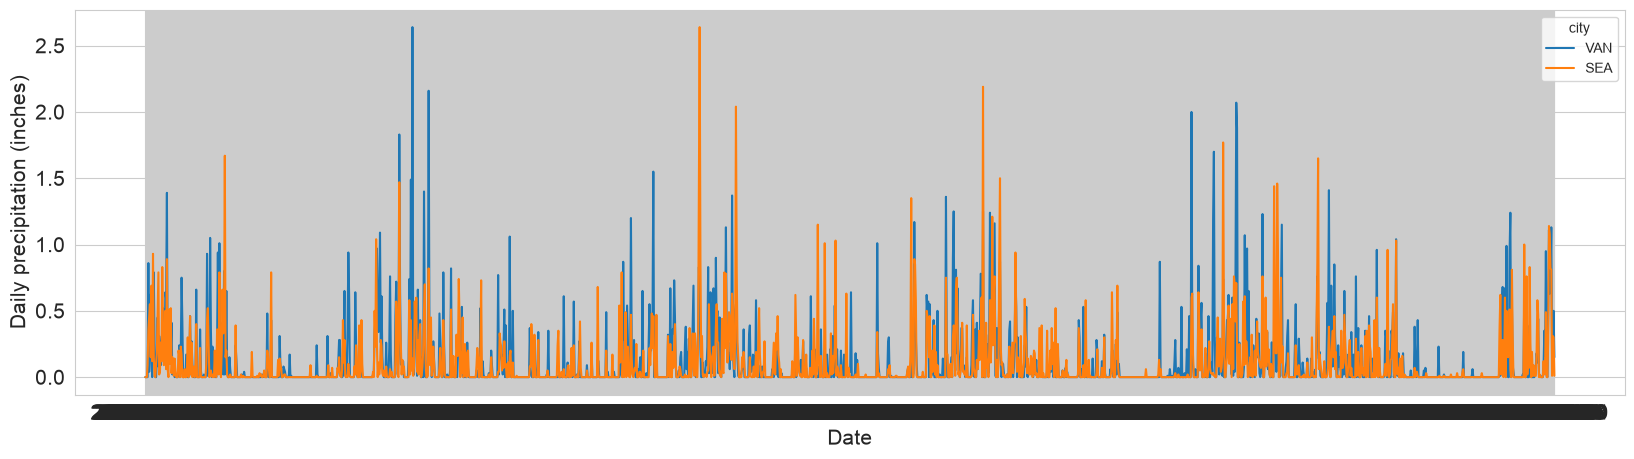

In [828]:
plt.figure(figsize=(20,5))

sns.lineplot(data=clean_df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

This line plot shows daily precipitation. 
The orange line represents precipitation in Seattle, while the blue line represents precipitation in Vancouver.
However, this graph is not enough to conclude which city rains more.

To examine the overall descriptive statistics of the dataset, we used describe().

In [829]:
clean_df[['city','precipitation']].groupby('city').describe()

precipitation                                               
             count      mean       std  min  25%  50%   75%   max
city                                                             
SEA         1826.0  0.104704  0.227059  0.0  0.0  0.0  0.11  2.64
VAN         1826.0  0.122128  0.258779  0.0  0.0  0.0  0.13  2.64

The descriptive statistics show that Seattle and Vancouver have similar means, standard deviations, and percentiles for precipitation.

### Precipitation analyze by full period of time

To visualize the mean precipitation for each city, we created a bar plot. Since `sns.barplot()` uses the mean as its default estimator, we do not need to specify the estimator explicitly.

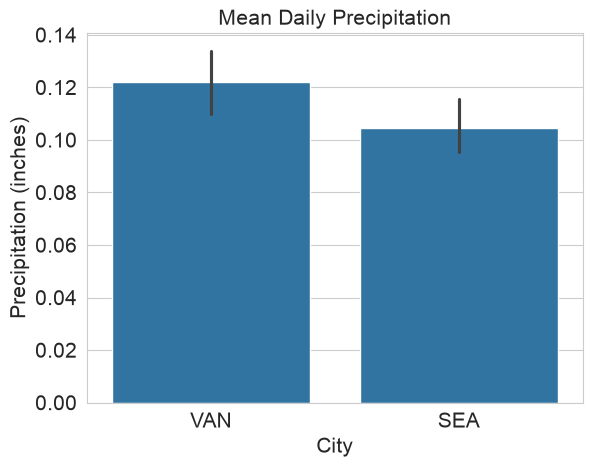

In [830]:
sns.barplot(data=clean_df, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

The graph shows that the overall mean daily precipitation is similar between the two cities, since the difference is less than 0.1 inches.
To examine the data in more detail, we will look at precipitation by month.

### Precipitation by month

Add a column to the data frame with the number of the month

In [831]:
clean_df['month'] = pd.DatetimeIndex(clean_df['date']).month
clean_df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,VAN,0.00,1,1
1,2018-01-02,VAN,0.00,2,1
2,2018-01-03,VAN,0.00,3,1
3,2018-01-04,VAN,0.00,4,1
4,2018-01-05,VAN,0.86,5,1


Now, we use box plots to examine the distribution of precipitation for each month. Since the precipitation data contain many zero values, a bar plot showing only the mean does not provide a complete view of the data. Box plots allow us to examine the distribution and identify potential outliers.

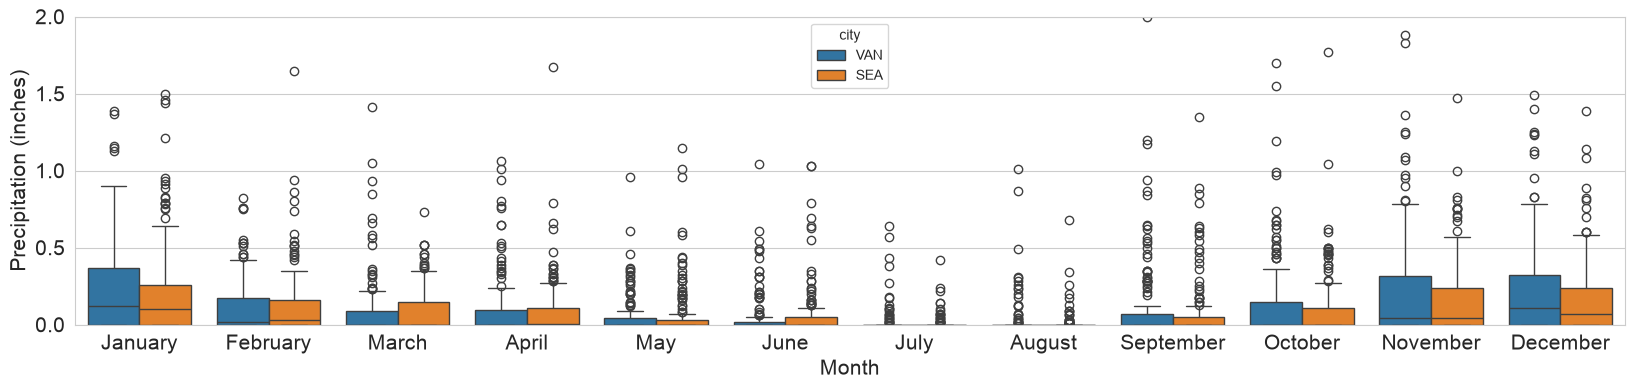

In [832]:
month_names =  list(calendar.month_name)[1:]
plt.figure(figsize=(20,4))

sns.boxplot(data=clean_df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.ylim(0, 2)

plt.show()


The graph shows that Seattle and Vancouver have similar seasonal precipitation patterns. Both cities receive more precipitation during the winter and less during the summer. However, Seattle appears to have lower precipitation than Vancouver in more months. Based on this observation, we will conduct one-sided tests to determine whether Seattle is drier than Vancouver.

We computed the mean and standard deviation of precipitation for each month. We used `unstack()` to organize the results into a more readable format, making it easier to compare the values at a glance. Without `unstack()`, the table would be longer and more difficult to compare.

In [833]:
clean_df[['month', 'precipitation', 'city']].groupby(['city','month'])['precipitation'].agg(['mean','std']).unstack('city')


mean                 std          
city        SEA       VAN       SEA       VAN
month                                        
1      0.215226  0.246452  0.310444  0.335284
2      0.144894  0.116206  0.277454  0.183051
3      0.089290  0.094645  0.143052  0.206568
4      0.090600  0.105333  0.189706  0.210521
5      0.071806  0.053613  0.178316  0.126388
6      0.069333  0.059133  0.173780  0.144305
7      0.012452  0.023403  0.047240  0.087946
8      0.016387  0.033355  0.068962  0.125493
9      0.083533  0.119333  0.203520  0.274247
10     0.105935  0.141548  0.217926  0.282662
11     0.162333  0.237333  0.251354  0.391762
12     0.197871  0.235694  0.356777  0.367628

This table allows us to examine the patterns observed in the graph more precisely using numerical values.

Mean precipitation is generally higher during the winter and lower during the summer in both cities.
In terms of magnitude, VAN gets more rain. VAN is higher in 9 of the 12 months, and the gap is largest in fall (September to November). November has the biggest difference at −0.075, where SEA is about 68% of VAN. In February, May, and June, SEA is higher.

### Precipitation by season

To analyze the data by season, we need to assign a season label to each observation. The code below assigns a season to each date.

We defined a function called `get_season`, which assigns months 12, 1, and 2 to winter; months 3, 4, and 5 to spring; and so on.

Then, we added a column named season to the clean_df.

In [834]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

clean_df['season'] = clean_df['month'].apply(get_season)
clean_df

,date,city,precipitation,day_of_year,month,season
0,2018-01-01,VAN,0.00,1,1,Winter
1,2018-01-02,VAN,0.00,2,1,Winter
2,2018-01-03,VAN,0.00,3,1,Winter
3,2018-01-04,VAN,0.00,4,1,Winter
4,2018-01-05,VAN,0.86,5,1,Winter
...,...,...,...,...,...,...
3647,2022-12-27,SEA,0.81,361,12,Winter
3648,2022-12-28,SEA,0.01,362,12,Winter
3649,2022-12-29,SEA,0.31,363,12,Winter
3650,2022-12-30,SEA,0.30,364,12,Winter


Now we use box plots to examine the distribution of precipitation for each season.

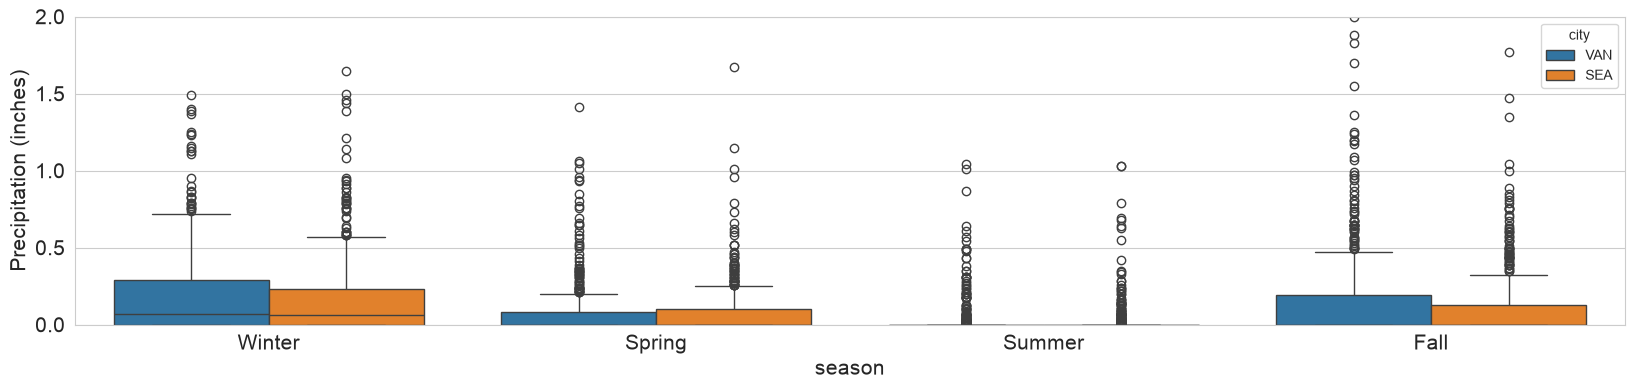

In [835]:
month_names =  list(calendar.month_name)[1:]
plt.figure(figsize=(20,4))

sns.boxplot(data=clean_df, x='season', y='precipitation', hue='city')

plt.xlabel('season', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(4), labels=['Winter', 'Spring', 'Summer', 'Fall'])

plt.ylim(0, 2)

plt.show()


We can still confirm that both cities show a very similar pattern throughout the seasons."

# Proportion of days with any precipitation

Now we want to know how frequently it rains in each cities.
In other words, we want to know about the proportion, not the absolute amount.
Therefore we need to add a variable to the data frame that indicates whether there was any precipitation

In [836]:
clean_df['any_precipitation'] = clean_df['precipitation'] >0
clean_df.head()

,date,city,precipitation,day_of_year,month,season,any_precipitation
0,2018-01-01,VAN,0.00,1,1,Winter,False
1,2018-01-02,VAN,0.00,2,1,Winter,False
2,2018-01-03,VAN,0.00,3,1,Winter,False
3,2018-01-04,VAN,0.00,4,1,Winter,False
4,2018-01-05,VAN,0.86,5,1,Winter,True


`any_precipitation` columns shows True when the precipitation is bigger than 0

### Full Period

Plot the proportion of days with any precipitation over the 5 years

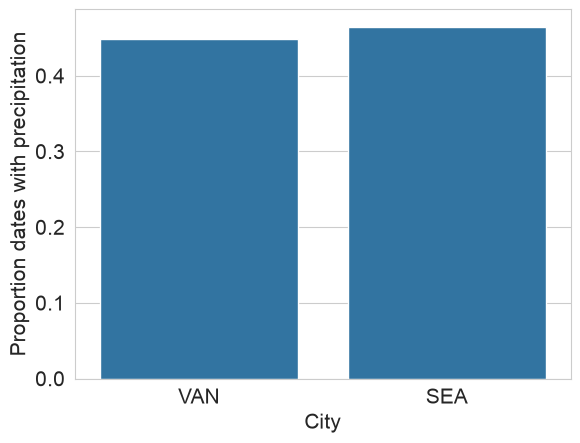

In [860]:
sns.barplot(data=clean_df, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion dates with precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

The graph shows Seattle has a higher frequency of rainy days than Vancouver.

Next, we examine the proportion of days with precipitation for each month. The bar plot below shows the proportion of rainy days by month.

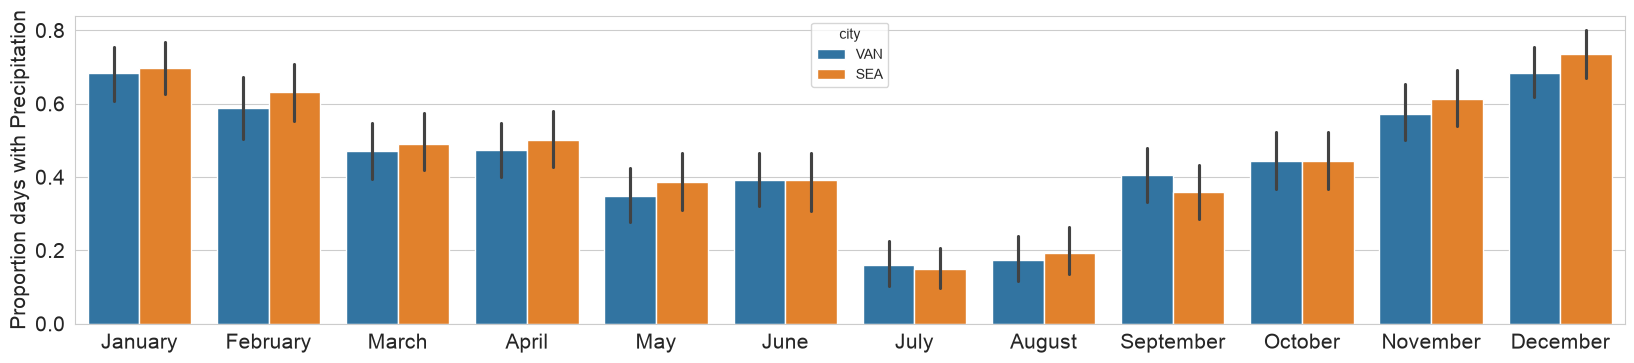

In [861]:
plt.figure(figsize=(20,4))

sns.barplot(data=clean_df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.show()


This bar plot shows that, the first half of the year proportion days with precipitation is higher in Seattle.

Below code draws a 12-panel histogram (one per month) comparing daily precipitation in Seattle and Vancouver, using identical 0.1-inch bins in every panel so the bars can be compared directly across months.

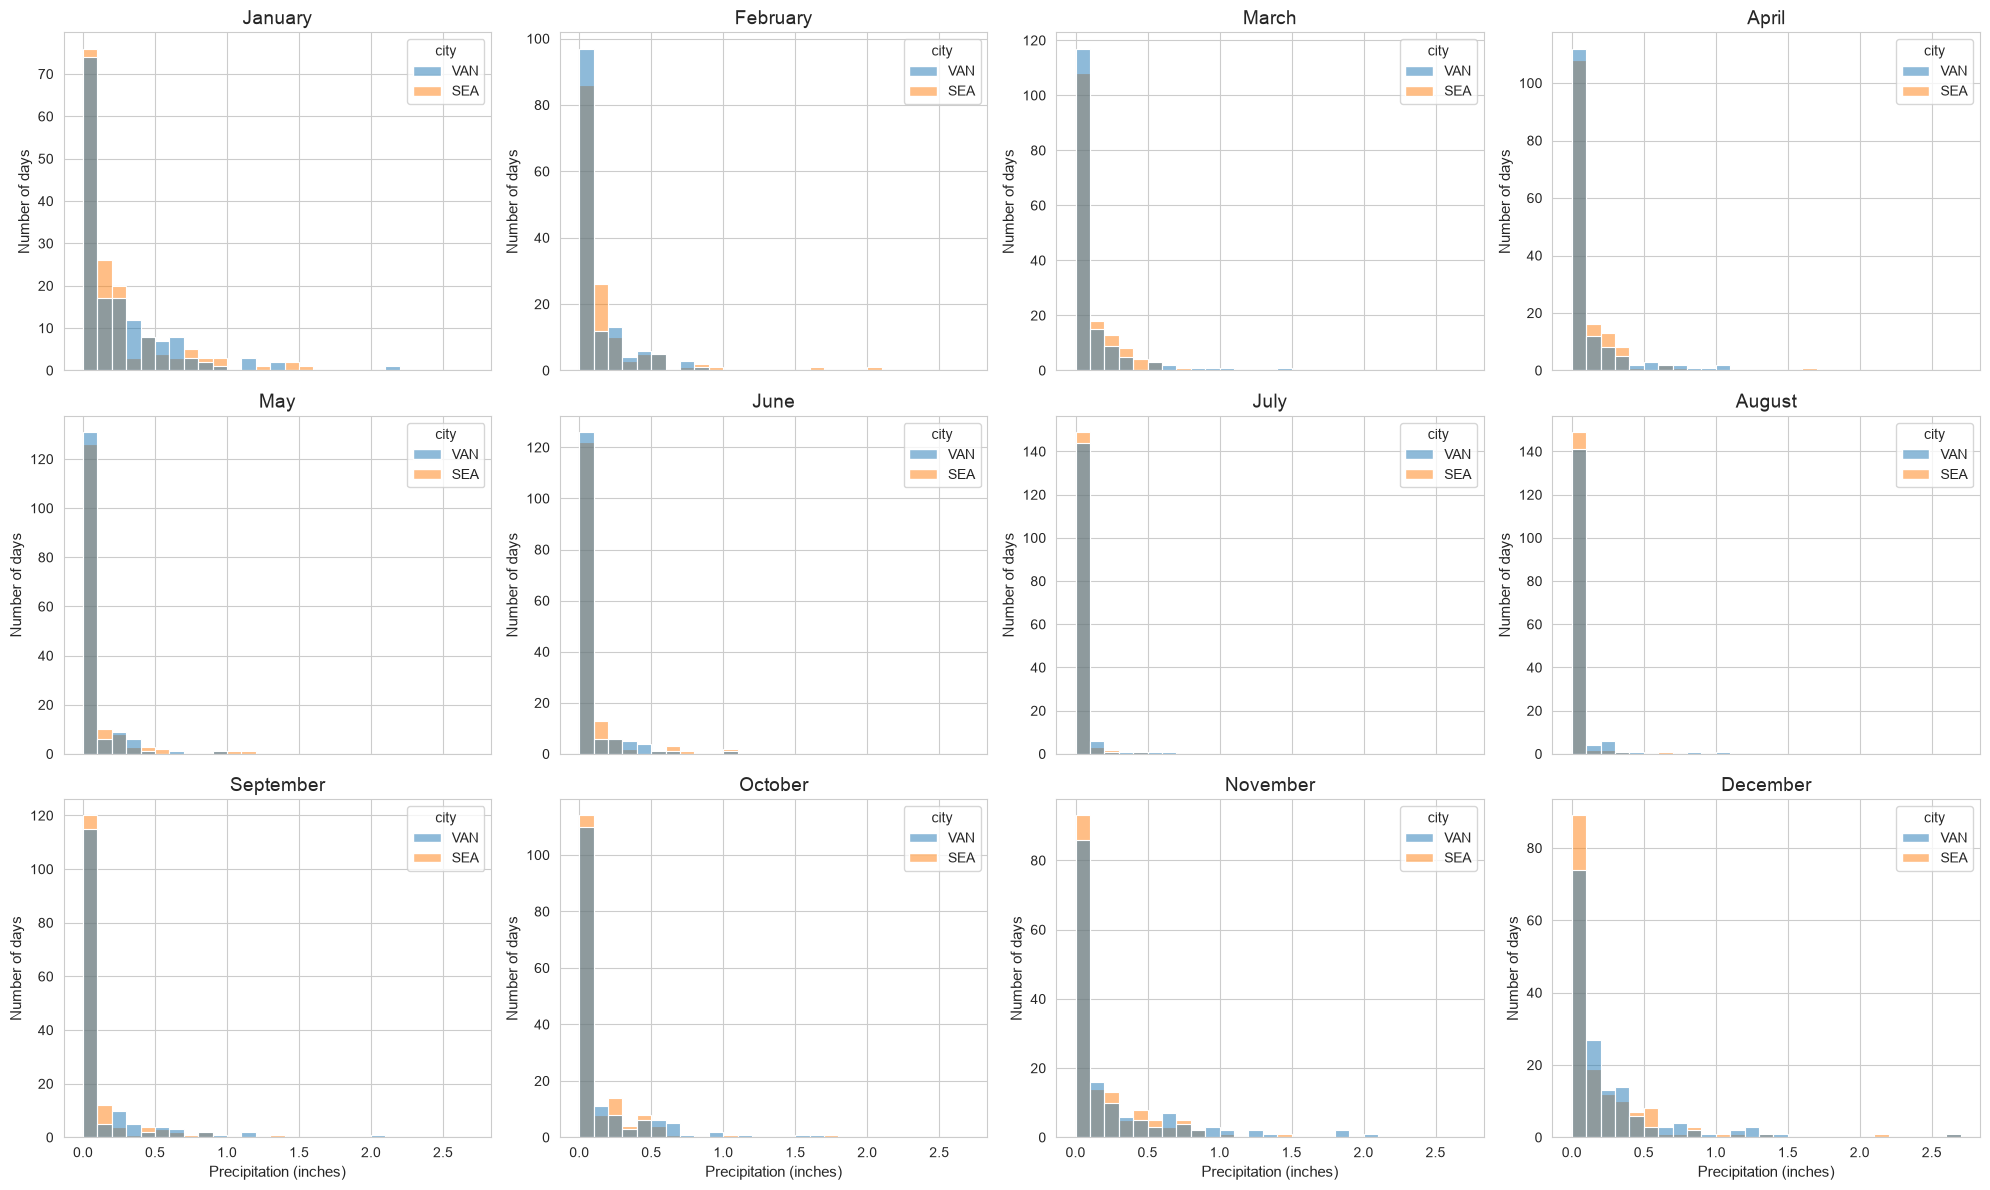

In [862]:
bin_width = 0.1
max_val = clean_df['precipitation'].max()
bins = np.arange(0, max_val + bin_width, bin_width)

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True)

for month, ax in zip(range(1, 13), axes.flat):
    sns.histplot(
        data=clean_df.loc[clean_df['month'] == month],
        x='precipitation',
        hue='city',
        bins=bins,          # same bins in every panel
        ax=ax
    )

    ax.set_title(calendar.month_name[month], fontsize=14)
    ax.set_xlabel('Precipitation (inches)', fontsize=11)
    ax.set_ylabel('Number of days', fontsize=11)

plt.tight_layout()
plt.show()

This graph shows the distribution of daily precipitation for the two cities over the study period. It provides a clearer picture of precipitation intensity because a day with 0 to 0.1 inches of precipitation may not feel meaningfully different from a day with only a trace amount of rain. The earlier graph counted any day with precipitation, even a trace amount, which showed a difference between the two cities but did not show how much precipitation fell on those days.
Comparing the two graphs helps us understand how people living in each city would actually have experienced the weather. In the earlier bar graph, June and October looked nearly identical for the two cities. In the histogram, however, Vancouver has more days in the first bin in June, while Seattle has more in October. This is because the first bin includes not only days with no rain at all but also days with up to 0.1 of rain. So even if the two cities looked the same when we only asked whether it rained, the answer can differ when we ask whether it barely rained or rained noticeably.

# Hypothesis Tests

## The amount of precipitation 

### By month

Now that we have visually explored the weather data, we will use statistical methods to test whether the differences between the two cities are statistically significant. First, we will conduct t-test to determine if Seattle rains more than Vancouver by month.

In [881]:
significance_level = 0.05
significantly_smaller = np.zeros(12)

#perfrom t-test for each month
for month in range(1,13):
    #Get precipitation data for Seattle and Vancouver for the current month
    sea_data = clean_df.loc[(clean_df['city'] == 'SEA') & (clean_df['month'] == month), 'precipitation']
    van_data = clean_df.loc[(clean_df['city'] == 'VAN') & (clean_df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, van_data, alternative='less', equal_var = False)

    if p_value < significance_level:
        significantly_smaller[month-1] = 1

        print(f"Month {month}:")
        print(f" t-statistic = {t_statistic:.2f}")
        print(f" p-value t test = {p_value:.3f}")
        print("-" * 20)

        
        

Month 11:
 t-statistic = -1.97
 p-value t test = 0.025
--------------------


We rejected the null hypothesis(μ_SEA ≥ μ_VAN) only in November, suggesting that Seattle had significantly lower mean daily precipitation than Vancouver in November.

Below is the visualization of the t-test.

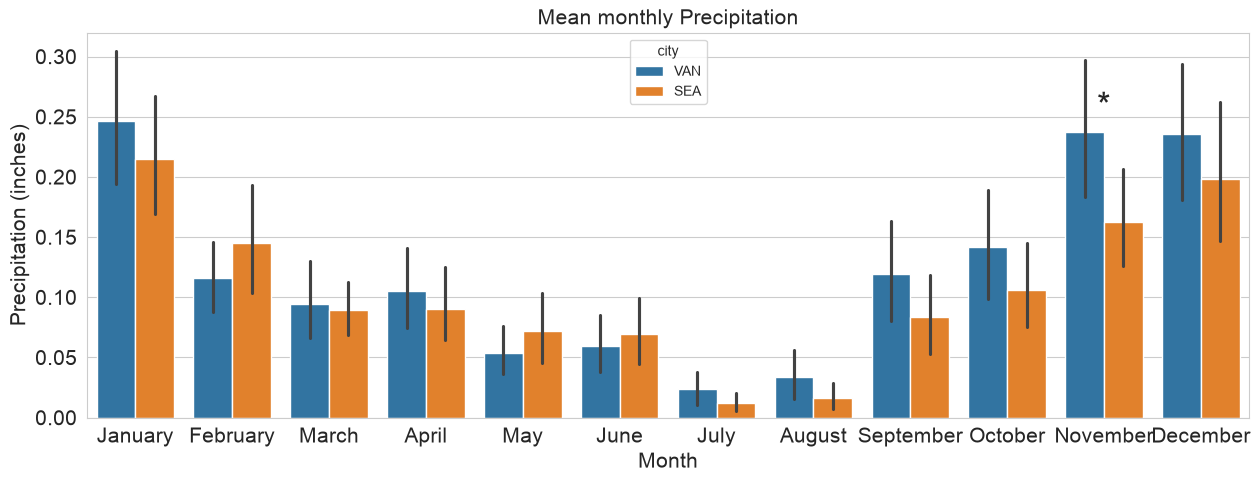

In [883]:
plt.figure(figsize=(15,5))

sns.barplot(data=clean_df, x='month', y='precipitation', hue='city', alpha=1)

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('Month', fontsize=15)
plt.title('Mean monthly Precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_smaller[month] == 1:
        #Add a star
        plt.text(month, 0.25, '*', ha='center', fontsize=25)
        
plt.show()

Here, the code marked * to the month when Seattle has significantly smaller precipitaion than Vancouver

### By season

Next, we use statistical methods to test whether the differences between the two cities are statistically significant across seasons.

In [879]:

significance_level = 0.05
significantly_different = np.zeros(4)

# Perform a t-test for each season
for season_index, season in enumerate(['Winter', 'Spring', 'Summer', 'Fall']):
    
    # Get precipitation data for Seattle and Vancouver for the current season
    sea_data = clean_df.loc[
        (clean_df['city'] == 'SEA') & (clean_df['season'] == season),
        'precipitation'
    ]
    
    van_data = clean_df.loc[
        (clean_df['city'] == 'VAN') & (clean_df['season'] == season),
        'precipitation'
    ]

    t_statistic, p_value = stats.ttest_ind(
        sea_data,
        van_data,
        alternative='less',
        equal_var=False
    )

    
    if p_value < significance_level:
        significantly_smaller[season_index] = 1

 
        print(f"Season {season}:")
        print(f"t-statistic = {t_statistic:.2f}")
        print(f"p-value = {p_value:.3f}")
        print("-" * 20)   


Season Fall:
t-statistic = -2.63
p-value = 0.004
--------------------


The t-test results show that there is no statistically significant evidence that Seattle receives less precipitation than Vancouver in winter, spring, or summer, as all p-values are greater than 0.05. However, in fall, the result is statistically significant (t = -2.63, p = 0.004). The negative t-statistic indicates that Seattle received significantly less precipitation than Vancouver during fall.

Below is the visualization of the t-test.

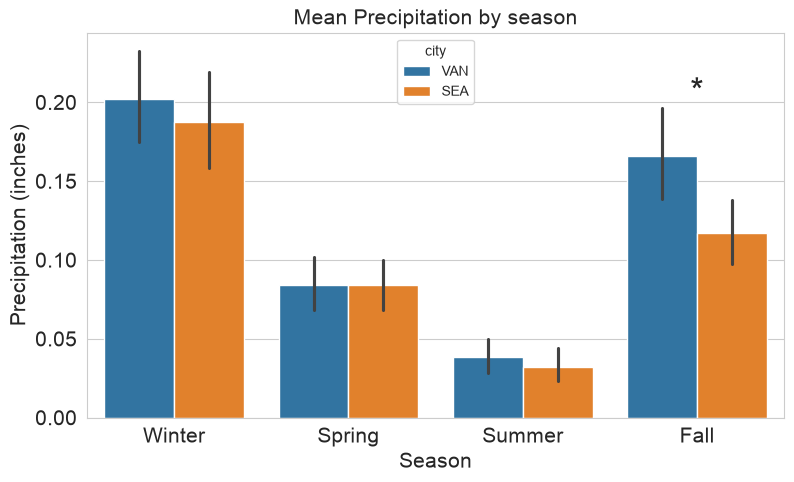

In [866]:
plt.figure(figsize=(9,5))

sns.barplot(data=clean_df, x='season', y='precipitation', hue='city', alpha=1)

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('Season', fontsize=15)
plt.title('Mean Precipitation by season', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(4), labels=['Winter', 'Spring', 'Summer', 'Fall'])

# Add stars for significantly smaller months

for season_index, season in enumerate(['Winter', 'Spring', 'Summer', 'Fall']):
    if significantly_smaller[season_index] == 1:
        plt.text(season_index, 0.2, '*', ha='center', fontsize=25)

plt.show()

Here, the code marked * to Fall, when Seattle has significantly smaller precipitaion than Vancouver

### By month

We now run a two-proportion z-test for each month to check whether the proportion of rainy days differs significantly between Seattle and Vancouver. Below is a one-sided test in the opposite direction because Seattle's overall proportion of rainy days was slightly higher than Vancouver's.

In [885]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform z-test for each month
for month in range(1,13):

    #Create a contingency table for Seattle and Vancouver for the current month:
    contingency_table = pd.crosstab(
        clean_df.loc[clean_df['month'] == month, 'city'], clean_df.loc[clean_df['month'] == month, 'any_precipitation']
    )

    # Calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]

    #Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)

    #Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='larger'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

        print(f"Month {month}:")
        print(f" z-statistic = {zstat:.2f}")
        print(f" p-value z test = {p_value:.3f}")
        print("-" * 20)
           

    

The two-proportion z-test shows that there is not enough statistical evidence to conclude that the proportion of rainy days is higher in Seattle than in Vancouver.

To visualize the z test, below is the bar plot with the test results.

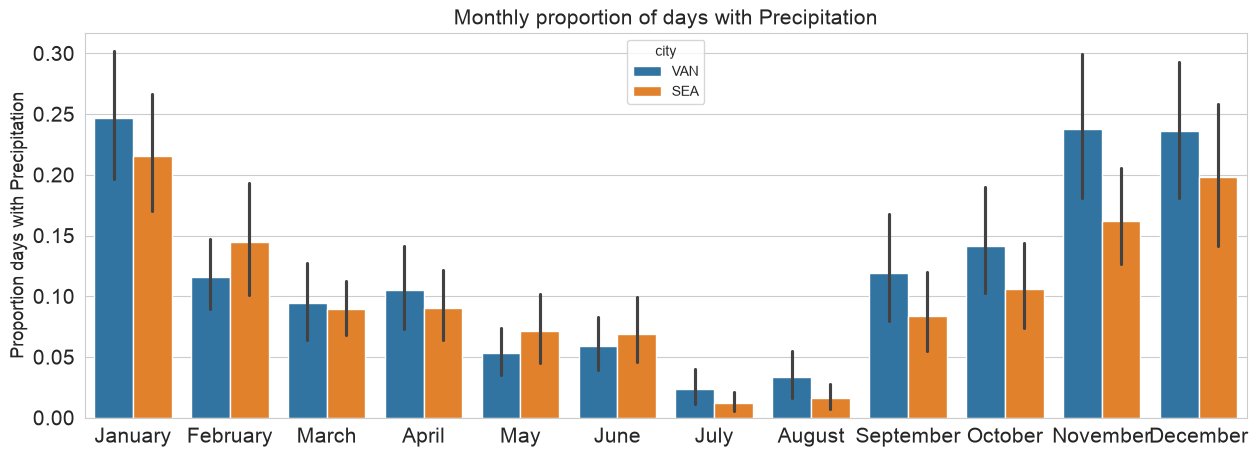

In [886]:
plt.figure(figsize=(15,5))

sns.barplot(data=clean_df, x='month', y='precipitation', hue='city', alpha=1)

plt.ylabel('Proportion days with Precipitation', fontsize=13)
plt.xlabel(None)
plt.title('Monthly proportion of days with Precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month] == 1:
        #Add a star
        plt.text(month, 0.25, '*', ha='center', fontsize=25)
        
plt.show()

Although the monthly bar plots show some visible differences in the proportion of rainy days, the z-test on the overall proportion did not find a statistically significant difference. This is likely because the overall difference is small relative to its standard error.

### By season

We now run a two-proportion z-test for each season to check whether the proportion of rainy days differs significantly between Seattle and Vancouver.

In [875]:
significance_level = 0.05
significantly_different_proportion = np.zeros(4)

# Perform a proportion z-test for each season
for season_index, season in enumerate(['Winter', 'Spring', 'Summer', 'Fall']):

    # Create a contingency table for Seattle and Vancouver for the current season
    contingency_table = pd.crosstab(
        clean_df.loc[clean_df['season'] == season, 'city'],
        clean_df.loc[clean_df['season'] == season, 'any_precipitation']
    )

    # Calculate the number of days with precipitation for each city
    days_with_precipitation = contingency_table[True]

    # Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)

    # Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation,
        nobs=total_counts,
        alternative='larger'
    )

    if p_value < significance_level:
        significantly_different_proportion[season_index] = 1

    print(f"Season {season}:")
    print(f"z-statistic = {zstat:.2f}")
    print(f"p-value = {p_value:.3f}")
    print("-" * 20)

Season Winter:
z-statistic = 1.13
p-value = 0.128
--------------------
Season Spring:
z-statistic = 0.86
p-value = 0.194
--------------------
Season Summer:
z-statistic = 0.08
p-value = 0.469
--------------------
Season Fall:
z-statistic = -0.07
p-value = 0.526
--------------------


This result also shows that the is no evidence that Seattle has a significantly higher frequency of rainy days than Vancouver in any seasons.

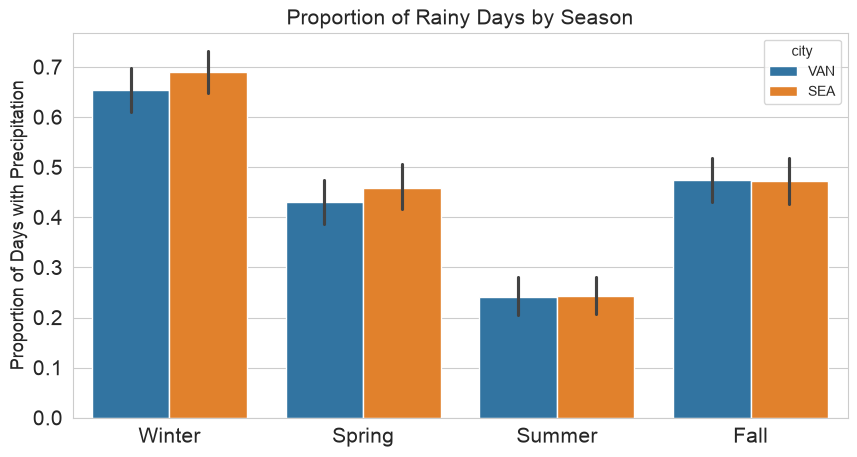

In [876]:

plt.figure(figsize=(10, 5))

sns.barplot(
    data=clean_df,
    x='season',
    y='any_precipitation',
    hue='city',
    order=['Winter', 'Spring', 'Summer', 'Fall']
)

plt.ylabel('Proportion of Days with Precipitation', fontsize=13)
plt.xlabel(None)
plt.title('Proportion of Rainy Days by Season', fontsize=15)

plt.tick_params(labelsize=15)

# Add stars for significantly different seasons
for season_index, season in enumerate(['Winter', 'Spring', 'Summer', 'Fall']):
    if significantly_different_proportion[season_index] == 1:
        plt.text(season_index, 0.8, '*', ha='center', fontsize=25)

plt.show()


This graph also shows that there is not much difference between Vancouver and Seattle.